# Elastic Augmentation — Base → READ

Same training setup as `trocr_READ.ipynb` (base → READ, LR=1e-5) but with **elastic deformation augmentation** on the training set.

**Why elastic?** It simulates natural handwriting variation: pen pressure differences, slight hand tremor, quill flexibility. Previous augmentation (RandomAffine + Blur) was too aggressive and changed global geometry instead of local stroke character.

**Augmentation pipeline (training only):**
| Transform | Effect | p |
|---|---|---|
| `ElasticTransform(α=40, σ=5)` | Local pixel displacement — simulates stroke variation | 0.6 |
| `Perspective(scale=0.02–0.05)` | Mild perspective warp — simulates page scan angle | 0.3 |
| `RandomBrightnessContrast(±0.15)` | Ink fading / darkening | 0.4 |
| `GaussNoise(std=0.02–0.06)` | Paper grain / scan noise | 0.3 |

Checkpoint: `../checkpoints/best_read_elastic/`

## Step 1 – Paths & Dataset Stats

In [1]:
import os
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

from pathlib import Path
import xml.etree.ElementTree as ET
from PIL import Image
import matplotlib.pyplot as plt

ROOT     = Path("..")
READ_DIR = ROOT / "data" / "READDataset"

SPLITS = {
    "train": {
        "images": READ_DIR / "Training" / "Images",
        "xmls":   READ_DIR / "Training" / "page" / "page",
    },
    "val": {
        "images": READ_DIR / "Validation" / "Images",
        "xmls":   READ_DIR / "Validation" / "page" / "page",
    },
    "test": {
        "images": READ_DIR / "Test-ICFHR-2016",
        "xmls":   READ_DIR / "Test-ICFHR-2016" / "page",
    },
}

PAGE_NS = "http://schema.primaresearch.org/PAGE/gts/pagecontent/2013-07-15"

print("Paths present:")
for split, paths in SPLITS.items():
    for key, p in paths.items():
        print(f"  {'✓' if p.exists() else '✗'} [{split}/{key}] {p}")

Paths present:
  ✓ [train/images] ../data/READDataset/Training/Images
  ✓ [train/xmls] ../data/READDataset/Training/page/page
  ✓ [val/images] ../data/READDataset/Validation/Images
  ✓ [val/xmls] ../data/READDataset/Validation/page/page
  ✓ [test/images] ../data/READDataset/Test-ICFHR-2016
  ✓ [test/xmls] ../data/READDataset/Test-ICFHR-2016/page


## Step 2 – XML Parsing & DataFrame

In [2]:
import pandas as pd
import xml.etree.ElementTree as ET
from pathlib import Path

KEEP_REGION_TYPES = {"paragraph", "heading"}
PAGE_NS           = "http://schema.primaresearch.org/PAGE/gts/pagecontent/2013-07-15"


def parse_page_xml(xml_path: Path, image_path: Path) -> list:
    ns = {"p": PAGE_NS}
    records = []
    for region in ET.parse(xml_path).getroot().findall(".//p:TextRegion", ns):
        rtype = region.get("type")
        if rtype is not None and rtype not in KEEP_REGION_TYPES:
            continue
        for line in region.findall(".//p:TextLine", ns):
            u      = line.find(".//p:Unicode", ns)
            coords = line.find("p:Coords", ns)
            if u is None or not (u.text or "").strip() or coords is None:
                continue
            pts  = coords.get("points", "")
            xs   = [int(p.split(",")[0]) for p in pts.split()]
            ys   = [int(p.split(",")[1]) for p in pts.split()]
            bbox = (min(xs), min(ys), max(xs), max(ys))
            if bbox[2] > bbox[0] and bbox[3] > bbox[1]:
                records.append({"image_path": str(image_path), "bbox": bbox,
                                 "transcription": u.text.strip()})
    return records


def build_dataframe(split_name: str) -> pd.DataFrame:
    paths, records = SPLITS[split_name], []
    for xml_file in sorted(paths["xmls"].glob("*.xml")):
        img_file = paths["images"] / (xml_file.stem + ".JPG")
        if img_file.exists():
            records.extend(parse_page_xml(xml_file, img_file))
    return pd.DataFrame(records)


df_train = build_dataframe("train")
df_val   = build_dataframe("val")
df_test  = build_dataframe("test")

print(f"Train : {len(df_train):>5} lines")
print(f"Val   : {len(df_val):>5} lines")
print(f"Test  : {len(df_test):>5} lines")

Train :  7140 lines
Val   :   894 lines
Test  :  1138 lines


## Step 3 – Seed & Image Loading

In [3]:
import random
import numpy as np
import torch

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark     = False
print(f"Random seed set to {SEED}")

Random seed set to 42


Crop size : (1212, 105)
Text      : 'mansdorf. Zū NeūPerg. Freÿ¬'


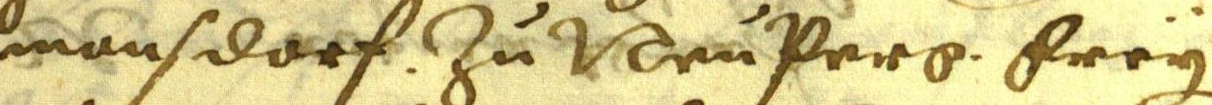

In [4]:
_page_cache: dict = {}

def load_line_image(image_path: str, bbox: tuple) -> Image.Image:
    if image_path not in _page_cache:
        _page_cache[image_path] = Image.open(image_path).convert("RGB")
    return _page_cache[image_path].crop(bbox)


row  = df_train.iloc[10]
crop = load_line_image(row["image_path"], row["bbox"])
print(f"Crop size : {crop.size}")
print(f"Text      : '{row['transcription']}'")
crop

## Step 4 – Augmentation Pipeline & Dataset

> Augmentation is applied **only to training images** — val/test use clean crops.

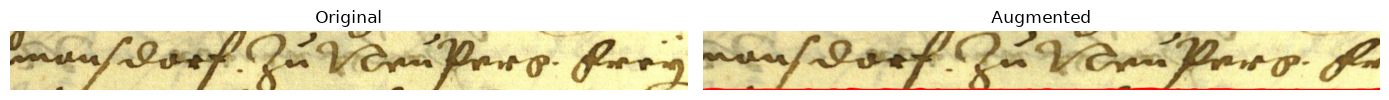

Augmentation pipeline OK.


In [5]:
import albumentations as A
import numpy as np

# albumentations 2.x API
aug_train = A.Compose([
    # Elastic deformation: local pixel displacement simulating stroke variation
    # alpha = deformation intensity, sigma = smoothness (higher = smoother)
    A.ElasticTransform(
        alpha=40.0,
        sigma=5.0,
        border_mode=0,   # constant border
        fill=255,        # white fill (document background)
        p=0.6,
    ),
    # Mild perspective warp: simulates page scan angle variation
    A.Perspective(
        scale=(0.02, 0.05),
        keep_size=True,
        border_mode=0,
        fill=255,
        p=0.3,
    ),
    # Ink fading / darkening variation
    A.RandomBrightnessContrast(
        brightness_limit=0.15,
        contrast_limit=0.15,
        p=0.4,
    ),
    # Paper grain / scan noise
    A.GaussNoise(
        std_range=(0.02, 0.06),
        p=0.3,
    ),
])

# Quick visual check on one crop
sample_img = load_line_image(df_train.iloc[10]["image_path"], df_train.iloc[10]["bbox"])
sample_np  = np.array(sample_img)
aug_np     = aug_train(image=sample_np)["image"]

fig, axes = plt.subplots(1, 2, figsize=(14, 2))
axes[0].imshow(sample_img); axes[0].set_title("Original"); axes[0].axis("off")
axes[1].imshow(aug_np);     axes[1].set_title("Augmented"); axes[1].axis("off")
plt.tight_layout()
plt.show()
print("Augmentation pipeline OK.")

In [6]:
from transformers import TrOCRProcessor
from torch.utils.data import Dataset, DataLoader

processor = TrOCRProcessor.from_pretrained("microsoft/trocr-base-handwritten")


class READDataset(Dataset):
    def __init__(self, df, processor, max_target_length=128, augment=False):
        self.df, self.processor = df, processor
        self.max_target_length  = max_target_length
        self.augment            = augment

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = load_line_image(row["image_path"], row["bbox"])

        if self.augment:
            img_np = np.array(img)
            img_np = aug_train(image=img_np)["image"]
            img    = Image.fromarray(img_np)

        pixel_values = self.processor(images=img, return_tensors="pt").pixel_values.squeeze(0)
        labels = self.processor.tokenizer(
            row["transcription"], padding="max_length",
            max_length=self.max_target_length, truncation=True, return_tensors="pt",
        ).input_ids.squeeze(0)
        labels[labels == self.processor.tokenizer.pad_token_id] = -100
        return {"pixel_values": pixel_values, "labels": labels}


train_loader = DataLoader(READDataset(df_train, processor, augment=True),
                          batch_size=16, shuffle=True,  num_workers=0)
val_loader   = DataLoader(READDataset(df_val,   processor, augment=False),
                          batch_size=16, shuffle=False, num_workers=0)

batch = next(iter(train_loader))
print(f"Batch pixel_values : {batch['pixel_values'].shape}")
print(f"Batch labels       : {batch['labels'].shape}")
print("DataLoaders OK — train has augmentation, val does not.")

/home/justin/Ginger_Gradient/14/project/Capstone-Project/.venv/lib/python3.11/site-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


Batch pixel_values : torch.Size([16, 3, 384, 384])
Batch labels       : torch.Size([16, 128])
DataLoaders OK — train has augmentation, val does not.


## Step 5 – Load Model

In [7]:
from transformers import VisionEncoderDecoderModel

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

model = VisionEncoderDecoderModel.from_pretrained("microsoft/trocr-base-handwritten")

model.config.decoder_start_token_id = processor.tokenizer.cls_token_id
model.config.pad_token_id           = processor.tokenizer.pad_token_id
model.config.eos_token_id           = processor.tokenizer.sep_token_id
model.config.use_cache              = False
model.gradient_checkpointing_enable()

model.to(device)
print("Model loaded from: microsoft/trocr-base-handwritten")

Device: cuda


/home/justin/Ginger_Gradient/14/project/Capstone-Project/.venv/lib/python3.11/site-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
Some weights of VisionEncoderDecoderModel were not initialized from the model checkpoint at microsoft/trocr-base-handwritten and are newly initialized: ['encoder.pooler.dense.bias', 'encoder.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Model loaded from: microsoft/trocr-base-handwritten


## Step 6 – Training

In [8]:
import evaluate
from pathlib import Path
from torch.optim import AdamW
from transformers import get_scheduler
from tqdm.notebook import tqdm

EPOCHS       = 30
LR           = 1e-5
WARMUP_RATIO = 0.1
PATIENCE     = 3
CKPT_DIR     = Path("../checkpoints/best_read_elastic")
CKPT_DIR.mkdir(parents=True, exist_ok=True)

total_steps  = EPOCHS * len(train_loader)
warmup_steps = int(total_steps * WARMUP_RATIO)

optimizer = AdamW(model.parameters(), lr=LR)
scheduler = get_scheduler(
    name="linear", optimizer=optimizer,
    num_warmup_steps=warmup_steps, num_training_steps=total_steps,
)

cer_metric = evaluate.load("cer")
wer_metric = evaluate.load("wer")

print(f"Total steps : {total_steps}  |  Warmup : {warmup_steps}  |  LR : {LR}")


def compute_metrics(model, dataloader, processor, device):
    model.eval()
    all_preds, all_refs = [], []
    with torch.no_grad():
        for batch in dataloader:
            pixel_values  = batch["pixel_values"].to(device)
            labels        = batch["labels"].clone()
            generated_ids = model.generate(pixel_values, max_new_tokens=128)
            preds = processor.batch_decode(generated_ids, skip_special_tokens=True)
            labels[labels == -100] = processor.tokenizer.pad_token_id
            refs  = processor.batch_decode(labels, skip_special_tokens=True)
            all_preds.extend(preds)
            all_refs.extend(refs)
    cer = cer_metric.compute(predictions=all_preds, references=all_refs)
    wer = wer_metric.compute(predictions=all_preds, references=all_refs)
    return cer, wer


best_cer         = float("inf")
patience_counter = 0
history          = []
scaler           = torch.amp.GradScaler("cuda")

if torch.cuda.is_available():
    torch.cuda.empty_cache()

for epoch in range(1, EPOCHS + 1):

    model.train()
    total_loss = 0.0

    for batch in tqdm(train_loader, desc=f"Epoch {epoch:02d}/{EPOCHS} [train]", leave=False):
        pixel_values = batch["pixel_values"].to(device)
        labels       = batch["labels"].to(device)
        optimizer.zero_grad()
        with torch.amp.autocast("cuda"):
            outputs = model(pixel_values=pixel_values, labels=labels)
        scaler.scale(outputs.loss).backward()
        scaler.step(optimizer)
        scaler.update()
        scheduler.step()
        total_loss += outputs.loss.item()

    avg_loss         = total_loss / len(train_loader)
    val_cer, val_wer = compute_metrics(model, val_loader, processor, device)

    history.append({"epoch": epoch, "train_loss": avg_loss,
                    "val_cer": val_cer, "val_wer": val_wer})
    print(f"Epoch {epoch:02d} | Loss: {avg_loss:.4f} | Val CER: {val_cer:.4f} | Val WER: {val_wer:.4f}", end="")

    if val_cer < best_cer:
        best_cer         = val_cer
        patience_counter = 0
        model.save_pretrained(CKPT_DIR)
        processor.save_pretrained(CKPT_DIR)
        print("  ✓ best saved")
    else:
        patience_counter += 1
        print(f"  ✗ No improvement ({patience_counter}/{PATIENCE})")
        if patience_counter >= PATIENCE:
            print(f"\nEarly stopping — best Val CER: {best_cer:.4f}")
            break

Total steps : 13410  |  Warmup : 1341  |  LR : 1e-05


Epoch 01/30 [train]:   0%|          | 0/447 [00:00<?, ?it/s]

Epoch 01 | Loss: 5.4067 | Val CER: 0.2654 | Val WER: 0.7214  ✓ best saved


Epoch 02/30 [train]:   0%|          | 0/447 [00:00<?, ?it/s]

Epoch 02 | Loss: 1.2719 | Val CER: 0.1342 | Val WER: 0.4795  ✓ best saved


...

Epoch 21 | Loss: 0.0820 | Val CER: 0.0614 | Val WER: 0.2604  ✗ No improvement (1/3)


Epoch 22/30 [train]:   0%|          | 0/447 [00:00<?, ?it/s]

Epoch 22 | Loss: 0.0852 | Val CER: 0.0619 | Val WER: 0.2685  ✗ No improvement (2/3)


Epoch 23/30 [train]:   0%|          | 0/447 [00:00<?, ?it/s]

Epoch 23 | Loss: 0.0726 | Val CER: 0.0607 | Val WER: 0.2688  ✗ No improvement (3/3)

Early stopping — best Val CER: 0.0599


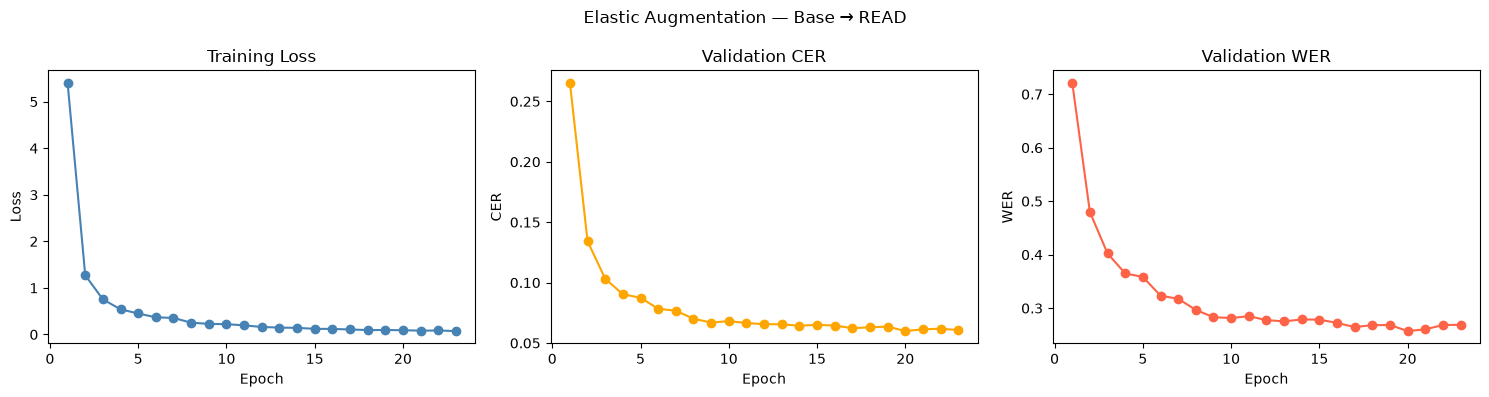

Best Val CER: 0.0599 (Epoch 20)


In [9]:
import pandas as pd

history_df = pd.DataFrame(history)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(history_df["epoch"], history_df["train_loss"], marker="o", color="steelblue")
axes[0].set_title("Training Loss")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss")

axes[1].plot(history_df["epoch"], history_df["val_cer"], marker="o", color="orange")
axes[1].set_title("Validation CER")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("CER")

axes[2].plot(history_df["epoch"], history_df["val_wer"], marker="o", color="tomato")
axes[2].set_title("Validation WER")
axes[2].set_xlabel("Epoch"); axes[2].set_ylabel("WER")

plt.suptitle("Elastic Augmentation — Base → READ", fontsize=12)
plt.tight_layout()
plt.show()
print(f"Best Val CER: {history_df['val_cer'].min():.4f} (Epoch {history_df['val_cer'].idxmin() + 1})")

## Step 7 – Evaluation

Self-contained: can be run after a kernel restart without retraining.

In [10]:
import torch
import evaluate
import xml.etree.ElementTree as ET
import pandas as pd
from pathlib import Path
from PIL import Image
from torch.utils.data import Dataset, DataLoader
from tqdm.notebook import tqdm
from transformers import VisionEncoderDecoderModel, TrOCRProcessor

READ_DIR          = Path("../data/READDataset")
CKPT_DIR          = Path("../checkpoints/best_read_elastic")
PAGE_NS           = "http://schema.primaresearch.org/PAGE/gts/pagecontent/2013-07-15"
KEEP_REGION_TYPES = {"paragraph", "heading"}

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def _parse_xml(xml_path, image_path):
    ns, records = {"p": PAGE_NS}, []
    for region in ET.parse(xml_path).getroot().findall(".//p:TextRegion", ns):
        rtype = region.get("type")
        if rtype is not None and rtype not in KEEP_REGION_TYPES:
            continue
        for line in region.findall(".//p:TextLine", ns):
            u      = line.find(".//p:Unicode", ns)
            coords = line.find("p:Coords", ns)
            if u is None or not (u.text or "").strip() or coords is None:
                continue
            pts  = coords.get("points", "")
            xs   = [int(p.split(",")[0]) for p in pts.split()]
            ys   = [int(p.split(",")[1]) for p in pts.split()]
            bbox = (min(xs), min(ys), max(xs), max(ys))
            if bbox[2] > bbox[0] and bbox[3] > bbox[1]:
                records.append({"image_path": str(image_path), "bbox": bbox,
                                 "transcription": u.text.strip()})
    return records

test_xml_dir = READ_DIR / "Test-ICFHR-2016" / "page"
test_img_dir = READ_DIR / "Test-ICFHR-2016"
records = []
for xml_file in sorted(test_xml_dir.glob("*.xml")):
    img_file = test_img_dir / (xml_file.stem + ".JPG")
    if img_file.exists():
        records.extend(_parse_xml(xml_file, img_file))
df_test_eval = pd.DataFrame(records)

best_model     = VisionEncoderDecoderModel.from_pretrained(CKPT_DIR).to(device)
best_processor = TrOCRProcessor.from_pretrained(CKPT_DIR)
best_model.eval()

print(f"Device     : {device}")
print(f"Checkpoint : {CKPT_DIR}")
print(f"Test lines : {len(df_test_eval)}")

Device     : cuda
Checkpoint : ../checkpoints/best_read_elastic
Test lines : 1138


In [11]:
class _READDataset(Dataset):
    def __init__(self, df, processor, max_target_length=128):
        self.df, self.processor = df, processor
        self.max_target_length  = max_target_length
        self._cache = {}

    def __len__(self): return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        if row["image_path"] not in self._cache:
            self._cache[row["image_path"]] = Image.open(row["image_path"]).convert("RGB")
        img          = self._cache[row["image_path"]].crop(row["bbox"])
        pixel_values = self.processor(images=img, return_tensors="pt").pixel_values.squeeze(0)
        labels = self.processor.tokenizer(
            row["transcription"], padding="max_length",
            max_length=self.max_target_length, truncation=True, return_tensors="pt",
        ).input_ids.squeeze(0)
        labels[labels == self.processor.tokenizer.pad_token_id] = -100
        return {"pixel_values": pixel_values, "labels": labels}


cer_metric = evaluate.load("cer")
wer_metric = evaluate.load("wer")

test_loader = DataLoader(
    _READDataset(df_test_eval, best_processor),
    batch_size=16, shuffle=False, num_workers=0,
)

all_preds, all_refs = [], []
with torch.no_grad():
    for batch in tqdm(test_loader, desc="Evaluating"):
        pixel_values  = batch["pixel_values"].to(device)
        labels        = batch["labels"].clone()
        generated_ids = best_model.generate(pixel_values, max_new_tokens=128)
        preds = best_processor.batch_decode(generated_ids, skip_special_tokens=True)
        labels[labels == -100] = best_processor.tokenizer.pad_token_id
        refs  = best_processor.batch_decode(labels, skip_special_tokens=True)
        all_preds.extend(preds)
        all_refs.extend(refs)

cer = cer_metric.compute(predictions=all_preds, references=all_refs)
wer = wer_metric.compute(predictions=all_preds, references=all_refs)

print(f"\nTest CER : {cer:.4f}  ({cer*100:.2f}%)")
print(f"Test WER : {wer:.4f}  ({wer*100:.2f}%)")

Evaluating:   0%|          | 0/72 [00:00<?, ?it/s]


Test CER : 0.0702  (7.02%)
Test WER : 0.2869  (28.69%)


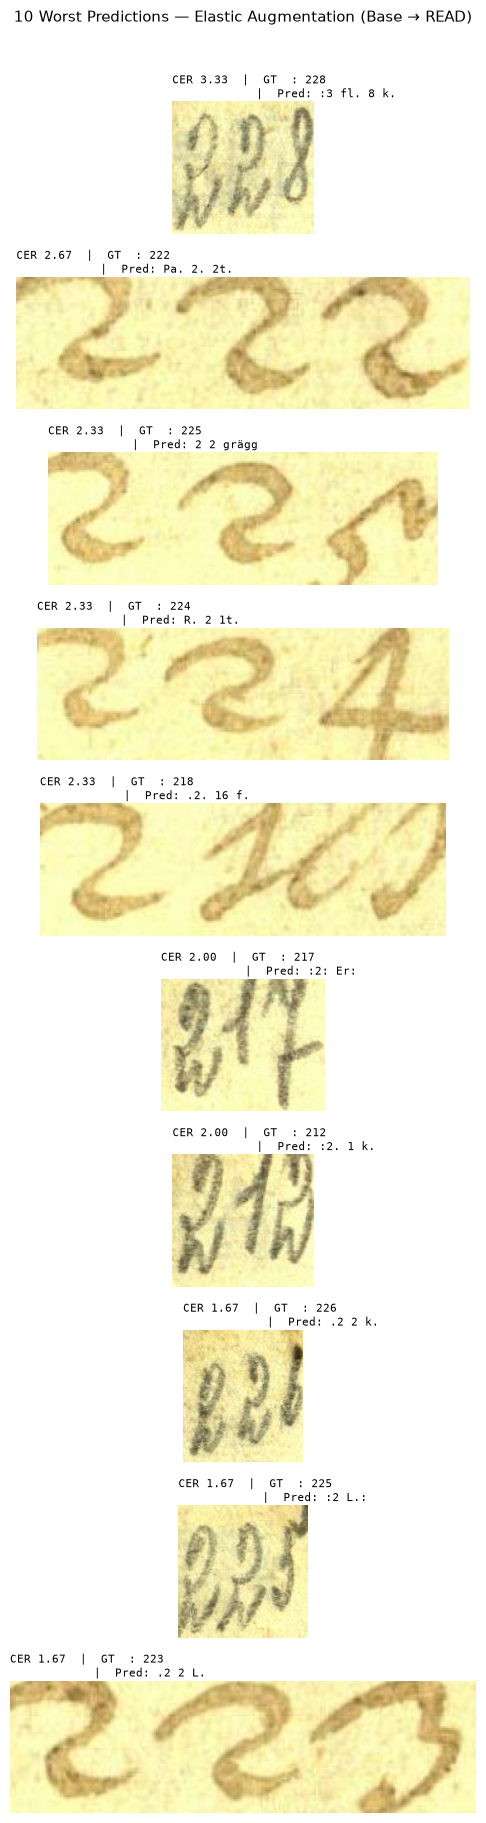

Saved to ../checkpoints/best_read_elastic/worst_predictions.png


In [12]:
import matplotlib.pyplot as plt
from jiwer import cer as line_cer

errors = sorted(
    [(line_cer(ref, pred), idx, ref, pred)
     for idx, (pred, ref) in enumerate(zip(all_preds, all_refs)) if ref.strip()],
    reverse=True,
)
worst = errors[:10]

fig, axes = plt.subplots(10, 1, figsize=(15, 18))
for ax, (c, idx, ref, pred) in zip(axes, worst):
    row = df_test_eval.iloc[idx]
    img = Image.open(row["image_path"]).crop(row["bbox"])
    ax.imshow(img)
    ax.set_title(
        f"CER {c:.2f}  |  GT  : {ref}\n"
        f"            |  Pred: {pred}",
        fontsize=8, loc="left", pad=3, family="monospace",
    )
    ax.axis("off")

plt.suptitle("10 Worst Predictions — Elastic Augmentation (Base → READ)", fontsize=11, y=1.01)
plt.tight_layout()

out_path = Path("../checkpoints/best_read_elastic/worst_predictions.png")
plt.savefig(out_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved to {out_path}")